# Experimento 01 — XOR: implementação manual vs. Keras

**Objetivo:** Implementar uma rede neural *na mão* para o problema XOR e comparar com uma versão equivalente usando Keras.

**Arquitetura:** `[2 → 2 → 1]` com sigmoide e bias.

## 1. Diagrama da rede

A figura mostra a arquitetura implementada: `[2 → 2 → 1]`, sigmoide nas duas camadas, com bias.

![Diagrama da rede neural para XOR](rede_neural.png)

## 2. Dataset

O dataset é o XOR clássico, com 4 amostras — o menor problema não linearmente separável.

| x1 | x2 | y |
|----|----|---|
| 0  | 0  | 0 |
| 0  | 1  | 1 |
| 1  | 0  | 1 |
| 1  | 1  | 0 |

![Dataset XOR](xor_dataset.png)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Dataset XOR
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
y = np.array([[0], [1], [1], [0]], dtype=float)

print("X =", X)
print("y =", y)

X = [[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]
y = [[0.]
 [1.]
 [1.]
 [0.]]


## 3. Hiperparâmetros e arquitetura

- Entrada: 2 · Camada oculta: 2 · Saída: 1
- Taxa de aprendizado: `lr = 0.1`
- Épocas: 5000

In [2]:
# quantidade de valores que entram na rede
n_inputs = 2
# quantidade de neurônios na camada escondida
n_hidden = 2
# quantidade de valores que saem da rede
n_outputs = 1
# taxa de aprendizado
lr = 0.1       
# número de épocas
epochs = 5000   

## 4. Função de ativação e sua derivada

Foi usada a sigmoide nas duas camadas:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

$$\sigma'(z) = \sigma(z) \cdot (1 - \sigma(z))$$

Na implementação, a derivada é calculada a partir da saída `a = sigmoid(z)` já disponível no forward:

```
sigmoid_derivative(a) = a * (1 - a)
```

In [3]:
def sigmoid(z):
    '''Retorna a sigmoide de z.'''
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(a):
    '''Retorna a derivada da sigmoide, dado a = sigmoid(z).'''
    return a * (1 - a)

## 5. Inicialização de pesos e biases

Pesos e biases foram inicializados com distribuição uniforme em [0, 1) (`np.random.rand`, `seed=42`), seguindo o `exemplo4.py`.

In [4]:
np.random.seed(42)

w0 = np.random.rand(n_inputs, n_hidden)
b0 = np.random.rand(n_hidden)
w1 = np.random.rand(n_hidden)
b1 = np.random.rand(n_outputs)

print("W0:", w0)
print("b0:", b0)
print("W1:", w1)
print("b1:", b1)

W0: [[0.37454012 0.95071431]
 [0.73199394 0.59865848]]
b0: [0.15601864 0.15599452]
W1: [0.05808361 0.86617615]
b1: [0.60111501]


## 6. Forward pass

O forward foi implementado **por amostra** (escalar), seguindo a estrutura do `exemplo4.py`:

1. `v_j = Σ_i x_i · w0[j,i] + b0[j]` → `a_j = sigmoid(v_j)`
2. `z2 = Σ_j a_j · w1[j] + b1` → `ŷ = sigmoid(z2)`

In [5]:
def forward(x, w0, b0, w1, b1):
    '''Retorna y_pred, z1, a1, z2 (guarde ativações para o backprop).'''

    v = np.array([0.0, 0.0])
    a = np.array([0.0, 0.0])

    s00 = x[0] * w0[0, 0]
    s01 = x[1] * w0[0, 1]
    s10 = x[0] * w0[1, 0]
    s11 = x[1] * w0[1, 1]
    s02 = s00 + s01
    s12 = s10 + s11
    v[0] = s02 + b0[0]
    v[1] = s12 + b0[1]
    a[0] = sigmoid(v[0])
    a[1] = sigmoid(v[1])
    s20 = w1[0] * a[0]
    s21 = w1[1] * a[1]
    s22 = s20 + s21
    v2 = s22 + b1[0]
    y_pred = sigmoid(v2)
    return y_pred, v, a, v2

## 7. Cálculo do erro e da loss

Erro `e = ŷ − y` e perda MSE:

$$\text{MSE} = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2$$

No backprop usa-se `L = ½e²` por amostra, de modo que `dL/de = e`.

In [6]:
def compute_error(y_true, y_pred):
    '''Retorna o erro e.'''
    return y_pred - y_true

def mse_loss(y_true, y_pred):
    '''Retorna a loss MSE.'''
    return np.mean((y_true - y_pred)**2)

In [7]:
# Teste com a primeira amostra
y_pred, z1, a1, z2 = forward(X[0], w0, b0, w1, b1)
print("y_pred:", y_pred)
print("z1:", z1)
print("a1:", a1)
print("z2:", z2)

e_test = compute_error(y[0, 0], y_pred)
loss_test = mse_loss(y[0, 0], y_pred)
print("erro:", e_test)
print("loss:", loss_test)

y_pred: 0.7501134012512863
z1: [0.15601864 0.15599452]
a1: [0.53892573 0.53891974]
z2: 1.099217186821689
erro: 0.7501134012512863
loss: 0.5626701147367733


## 8. Backpropagation manual

O backprop foi implementado à mão, por amostra, seguindo o grafo de gradientes da figura:

![Backpropagation para XOR](ex01_xor_bp.jpg)

Ordem dos gradientes:

- `grad_v2 = e · ŷ(1−ŷ)`
- `grad_w1[j] = grad_v2 · a1[j]` · `grad_b1 = grad_v2`
- `grad_vj = grad_v2 · w1[j] · a1[j](1−a1[j])`
- `grad_b0[j] = grad_vj` · `grad_w0[j,i] = grad_vj · x_i`

In [8]:
def backprop(x_i, d, y_pred, a1, w0, b0, w1, b1):
    '''Backprop para UMA amostra x_i com rótulo d. Retorna grad_w0, grad_b0, grad_w1, grad_b1.

    z1 e z2 não são necessários: a derivada da sigmoide sai da saída
    (σ' = a·(1−a)), então basta y_pred e a1.
    '''
    grad_w0 = np.zeros_like(w0)
    grad_b0 = np.zeros_like(b0)
    grad_w1 = np.zeros_like(w1)
    grad_b1 = np.zeros_like(b1)

    # L = 1/2 * e^2  =>  dL/de = e
    e = y_pred - d
    grad_v2 = e * y_pred * (1 - y_pred)        # sigmoid'(z2)

    grad_b1[0] = grad_v2
    grad_w1[0] = grad_v2 * a1[0]
    grad_w1[1] = grad_v2 * a1[1]

    # propaga para a camada oculta: grad_y_j = grad_v2 * w1[j]
    grad_v0 = grad_v2 * w1[0] * a1[0] * (1 - a1[0])   # sigmoid'(v0)
    grad_v1 = grad_v2 * w1[1] * a1[1] * (1 - a1[1])   # sigmoid'(v1)

    grad_b0[0] = grad_v0
    grad_b0[1] = grad_v1
    grad_w0[0, 0] = grad_v0 * x_i[0]
    grad_w0[0, 1] = grad_v0 * x_i[1]
    grad_w0[1, 0] = grad_v1 * x_i[0]
    grad_w0[1, 1] = grad_v1 * x_i[1]

    return grad_w0, grad_b0, grad_w1, grad_b1

dW0, db0, dW1, db1 = backprop(X[0], y[0, 0], y_pred, a1, w0, b0, w1, b1)
print("dW0:", dW0)
print("db0:", db0)
print("dW1:", dW1)
print("db1:", db1)

dW0: [[0. 0.]
 [0. 0.]]
db0: [0.00202932 0.03026242]
dW1: [0.07577496 0.07577412]
db1: [0.14060372]


## 9. Treinamento manual

Gradiente descendente em batch: em cada época, o forward e o backprop rodam para as 4 amostras, os gradientes são **somados** e os pesos atualizados uma vez — como no `exemplo4.py`. A loss (MSE) é registrada por época para o gráfico.

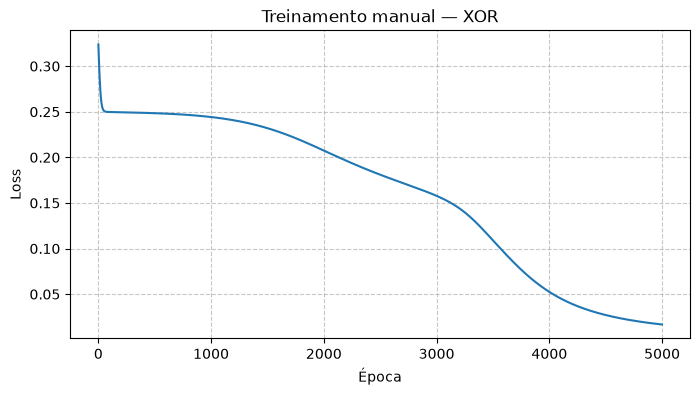

In [9]:
def train_manual(X, y, w0, b0, w1, b1, lr, epochs):
    '''Retorna os pesos treinados e a lista de losses (MSE por época).'''
    losses = []
    for epoch in range(epochs):
        grad_w0 = np.zeros_like(w0)
        grad_b0 = np.zeros_like(b0)
        grad_w1 = np.zeros_like(w1)
        grad_b1 = np.zeros_like(b1)
        loss = 0.0

        for k in range(len(X)):
            y_pred, z1, a1, z2 = forward(X[k], w0, b0, w1, b1)
            loss += mse_loss(y[k, 0], y_pred)
            g_w0, g_b0, g_w1, g_b1 = backprop(X[k], y[k, 0], y_pred, a1, w0, b0, w1, b1)
            grad_w0 += g_w0
            grad_b0 += g_b0
            grad_w1 += g_w1
            grad_b1 += g_b1

        w0 -= lr * grad_w0
        b0 -= lr * grad_b0
        w1 -= lr * grad_w1
        b1 -= lr * grad_b1
        losses.append(loss / len(X))
    return w0, b0, w1, b1, losses

w0_t, b0_t, w1_t, b1_t, losses = train_manual(X, y, w0, b0, w1, b1, lr, epochs)

plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel('Época')
plt.ylabel('Loss')
plt.title('Treinamento manual — XOR')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [10]:
# Predições finais
preds = np.array([forward(X[k], w0_t, b0_t, w1_t, b1_t)[0] for k in range(len(X))])
print("Predições:", preds)
print("Esperado:  ", y.ravel())
print("Acurácia:", np.mean((preds > 0.5) == y.ravel()))

Predições: [0.11989143 0.87505615 0.87396264 0.14534593]
Esperado:   [0. 1. 1. 0.]
Acurácia: 1.0


## 10. Keras baseline

A mesma arquitetura `[2 → 2 → 1]` com sigmoide foi implementada em Keras (backend torch, `seed=42`).

Como o manual **soma** os gradientes das 4 amostras e o SGD do Keras usa a **média** (com perda e², não ½e²), a taxa de aprendizado foi compensada: `lr_keras = lr × N = 0.4`.

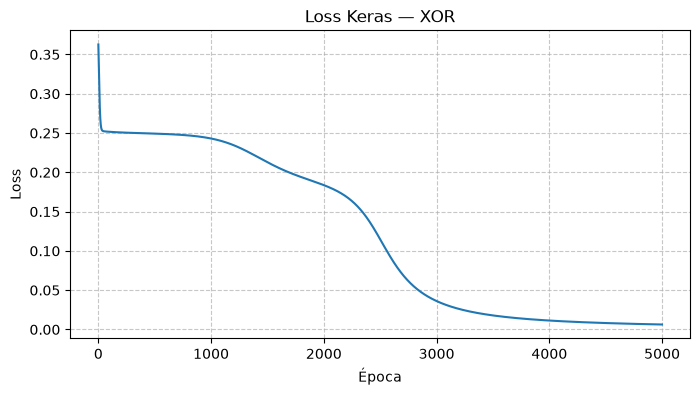

Acurácia Keras: 1.0


In [11]:
import os
os.environ["KERAS_BACKEND"] = "torch"

import keras
from keras.models import Sequential
from keras.layers import Dense, Input
from keras.optimizers import SGD

keras.utils.set_random_seed(42)

model = Sequential([
    Input(shape=(n_inputs,)),
    Dense(n_hidden, activation='sigmoid'),
    Dense(n_outputs, activation='sigmoid'),
])

# O manual SOMA os gradientes das 4 amostras; o SGD do Keras usa a média
# (e a perda dele é e^2, não 1/2 e^2). Para a comparação ser justa,
# compensamos a taxa de aprendizado.
lr_keras = lr * len(X)
model.compile(loss='mean_squared_error', optimizer=SGD(learning_rate=lr_keras),
              metrics=['accuracy'])

history = model.fit(X, y, epochs=epochs, batch_size=len(X), verbose=0)

plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'])
plt.xlabel('Época')
plt.ylabel('Loss')
plt.title('Loss Keras — XOR')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print("Acurácia Keras:", model.evaluate(X, y, verbose=0)[1])

## 11. Comparação: manual vs. Keras

As duas curvas de loss lado a lado. Resultado: ambas convergem com acurácia 100% — a diferença de fase na saída do platô vem da inicialização.

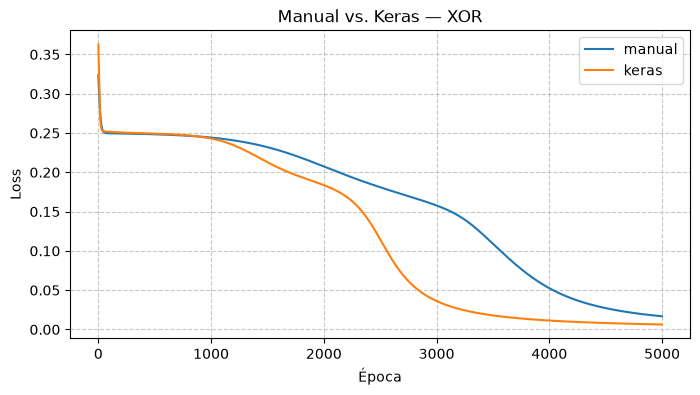

In [12]:
plt.figure(figsize=(8, 4))
plt.plot(losses, label='manual')
plt.plot(history.history['loss'], label='keras')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.title('Manual vs. Keras — XOR')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## 12. Fronteira de decisão

A fronteira aprendida pela rede manual: uma banda diagonal separa (0,0)+(1,1) de (0,1)+(1,0) — a rede aprendeu a estrutura do XOR, não apenas memorizou os pontos.

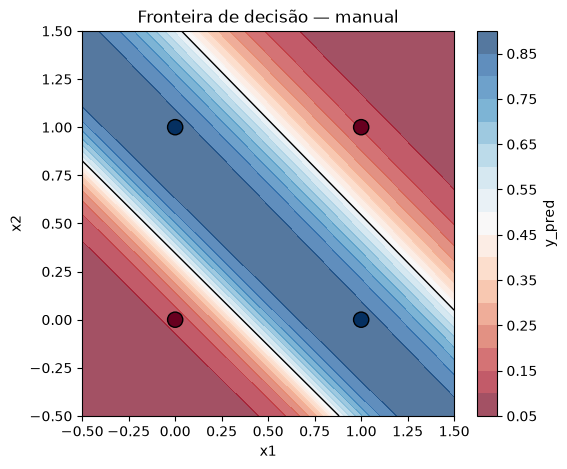

In [13]:
xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200),
                     np.linspace(-0.5, 1.5, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = np.array([forward(p, w0_t, b0_t, w1_t, b1_t)[0] for p in grid])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(6, 5))
plt.contourf(xx, yy, Z, levels=20, cmap='RdBu', alpha=0.7)
plt.colorbar(label='y_pred')
plt.scatter(X[:, 0], X[:, 1], c=y.ravel(), cmap='RdBu',
            edgecolors='black', s=120)
plt.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=1)
plt.title('Fronteira de decisão — manual')
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

## 13. Anotações e conclusões

**Convergência manual.** A loss ficou num patamar em ≈ 0.25 até ~época 1500, depois desceu rápido e estabilizou em ≈ 0.02 nas 5000 épocas. Esse platô é o ponto de sela clássico do XOR: os gradientes ficam minúsculos enquanto a rede "decide" para que lado quebrar a simetria. Predições finais `[0.12, 0.88, 0.87, 0.15]` vs. esperado `[0, 1, 1, 0]` → acurácia 100%.

**Inicialização.** Pesos uniformes em [0, 1) com `seed=42` funcionaram. A convergência do XOR com apenas 2 neurônios ocultos é muito sensível à inicialização — outras seeds podem travar no sela ou demorar bem mais para escapar.

**Taxa de aprendizado.** `lr=0.1` foi adequada para a versão manual porque o treino **soma** os gradientes das 4 amostras antes de atualizar (passo efetivo ≈ 4× maior que a média). Não houve oscilação nem divergência.

**Manual vs. Keras.** Resultado mais interessante do experimento:

- Com `lr=0.1`, o Keras **não aprendeu**: loss travada em ≈ 0.25, acurácia 0.5 (ficou preso no mesmo sela).
- Com `lr_keras = lr × N = 0.4` e `seed=42`: convergiu para loss ≈ 0.006, acurácia 100%.
- Com `lr_keras = 0.2` (equivalência exata de passo): classifica certo, mas converge mais devagar (loss ≈ 0.11 em 5000 épocas).
- Com `lr=0.1` o Keras só escapa do sela com ~30k épocas; com `lr=0.05` nem isso.

**Soma vs. média dos gradientes.** O manual faz `w -= lr × Σ gradientes` (4 amostras, perda ½e² → gradiente `e·∂ŷ`). O SGD do Keras faz `w -= lr_k × média` (perda e² → gradiente `2e·∂ŷ`, dividido por N=4). Com o mesmo lr, o passo do Keras é ~8× menor — daí a necessidade de compensar. Equivalência exata: `lr_keras = lr × N/2 = 0.2`.

**Fronteira de decisão.** A rede aprendeu uma banda diagonal que separa (0,0)+(1,1) de (0,1)+(1,0) — ou seja, aprendeu a estrutura do XOR e não apenas memorizou os 4 pontos.

**O que a implementação manual ensinou.**

- A derivada da sigmoide sai direto da saída: `σ'(z) = a(1-a)` — não precisa guardar `z`. Por isso o `backprop` recebe só `x_i, d, y_pred, a1` (além dos pesos): `z1` e `z2` seriam variáveis sobrando.
- Gradientes de bias são os próprios `grad_v` da camada (derivada de `v = s + b` em relação a `b` é 1).
- Shapes importam: o bug do `w1` com shape `(2,2)` em vez de `(2,)` fez `y_pred` virar vetor de 2 elementos sem erro nenhum — só apareceu no print. Num grafo escalar, um shape errado pode falhar em silêncio.
- Convenção de índices: `w0[j, i]` = peso da entrada `i` para o neurônio oculto `j` — o código, o `exemplo4.py` e o `formulas.txt` usam a mesma convenção.

**O sela do XOR.** O XOR é pequeno mas não trivial: a paisagem de loss tem um sela largo em ≈ 0.25 onde a rede prediz ~0.5 para tudo. Sair dele depende de inicialização + tamanho do passo (soma vs. média) — não de "mais épocas" necessariamente.
